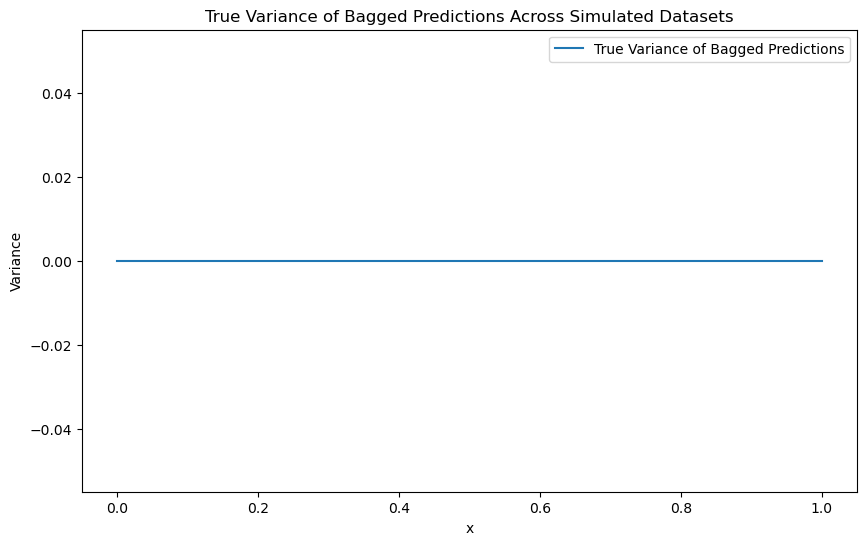

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

''' data for this simulation was drawn from 
a model y_i = f(x_i) + ε_i, where xi ~ U([0, 1]), ε_i ~ N (0, 1/4), 
and f(x) is the step function'''


# Define the step function as the true function
def step_function(x):
    return np.where(x < 0.35, 0, np.where(x < 0.45, 0.7, np.where(x < 0.55, 1.4, np.where(x < 0.65, 0.7, 0))))

# Simulation parameters
np.random.seed(42)
n_data_points = 500
n_simulations = 1  # Number of different datasets to simulate
n_bootstrap = 100  # Number of bootstrap samples for bagging
x_values = np.linspace(0, 1, n_data_points)
y_true = step_function(x_values)

# Array to store the predictions from each simulation
bagged_predictions = np.zeros((n_simulations, n_data_points))

# Generate multiple simulated datasets and perform predictions
for i in range(n_simulations):
    noise = np.random.normal(0, np.sqrt(0.25), n_data_points)
    y_noisy = y_true + noise

    # Bagging and prediction
    tree_model = DecisionTreeRegressor(max_leaf_nodes=5)
    tree_predictions = np.zeros((n_bootstrap, n_data_points))
    
    for b in range(n_bootstrap):
        indices = np.random.choice(n_data_points, n_data_points, replace=True)
        tree_model.fit(x_values[indices].reshape(-1, 1), y_noisy[indices])
        tree_predictions[b, :] = tree_model.predict(x_values.reshape(-1, 1))
    
    # Average predictions across bootstrap samples
    bagged_predictions[i, :] = tree_predictions.mean(axis=0)

# Calculate true variance of bagged predictions
true_variances = bagged_predictions.var(axis=0)




In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(x_values, true_variances, label='True Variance of Bagged Predictions')
plt.title('True Variance of Bagged Predictions Across Simulated Datasets')
plt.xlabel('x')
plt.ylabel('Variance')
plt.legend()
plt.show()



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
import concurrent.futures
import os

# Define the step function as the true function
def step_function(x):
    return np.where(x < 0.35, 0, np.where(x < 0.45, 0.7, np.where(x < 0.55, 1.4, np.where(x < 0.65, 0.7, 0))))

# Simulation parameters
np.random.seed(42)
n_data_points = 500
n_simulations = 1000  # Number of different datasets to simulate
n_bootstrap = 100  # Number of bootstrap samples for bagging
x_values = np.linspace(0, 1, n_data_points)
y_true = step_function(x_values)

# Array to store the predictions from each simulation
bagged_predictions = np.zeros((n_simulations, n_data_points))

def simulate_and_predict(i):
    np.random.seed(os.getpid() ^ int.from_bytes(os.urandom(4), byteorder='little'))
    noise = np.random.normal(0, np.sqrt(0.25), n_data_points)
    y_noisy = y_true + noise

    # Bagging and prediction
    tree_model = DecisionTreeRegressor(max_leaf_nodes=5)
    tree_predictions = np.zeros((n_bootstrap, n_data_points))
    
    for b in range(n_bootstrap):
        indices = np.random.choice(n_data_points, n_data_points, replace=True)
        tree_model.fit(x_values[indices].reshape(-1, 1), y_noisy[indices])
        tree_predictions[b, :] = tree_model.predict(x_values.reshape(-1, 1))
    
    # Average predictions across bootstrap samples
    return tree_predictions.mean(axis=0)

# Use a ProcessPoolExecutor to parallelize the simulation and prediction
with concurrent.futures.ProcessPoolExecutor() as executor:
    futures = {executor.submit(simulate_and_predict, i) for i in range(n_simulations)}
    bagged_predictions = [future.result() for future in concurrent.futures.as_completed(futures)]

# Calculate true variance of bagged predictions
true_variances = np.var(bagged_predictions, axis=0)
print(true_variances)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(x_values, true_variances, label='True Variance of Bagged Predictions')
plt.title('True Variance of Bagged Predictions Across Simulated Datasets')
plt.xlabel('x')
plt.ylabel('Variance')
plt.legend()
plt.show()

Traceback (most recent call last):
  File "c:\Users\rehan\anaconda3\envs\Master-Thesis\Lib\multiprocessing\queues.py", line 246, in _feed
    send_bytes(obj)
  File "c:\Users\rehan\anaconda3\envs\Master-Thesis\Lib\multiprocessing\connection.py", line 184, in send_bytes
    self._check_closed()
  File "c:\Users\rehan\anaconda3\envs\Master-Thesis\Lib\multiprocessing\connection.py", line 137, in _check_closed
    raise OSError("handle is closed")
OSError: handle is closed
Traceback (most recent call last):
  File "c:\Users\rehan\anaconda3\envs\Master-Thesis\Lib\multiprocessing\queues.py", line 246, in _feed
    send_bytes(obj)
  File "c:\Users\rehan\anaconda3\envs\Master-Thesis\Lib\multiprocessing\connection.py", line 184, in send_bytes
    self._check_closed()
  File "c:\Users\rehan\anaconda3\envs\Master-Thesis\Lib\multiprocessing\connection.py", line 137, in _check_closed
    raise OSError("handle is closed")
OSError: handle is closed
Traceback (most recent call last):
  File "c:\Users\

OSError: handle is closed